# Relación entre pluviómetro y boyas

## Pluviometros en el curso de la rambla del Albujón y Boya CTD7 

In [1]:
# pyenv activate nitrates
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller

## Pluviómetros

Cargamos los datos de todos los pluviómetros disponibles

In [188]:
path = "Ramblas/"
# Diccionario para almacenar los dataframes
dataframes = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Pluviometro.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}_pluviometro"
                # Almacenar el dataframe en el diccionario
                dataframes[nombre_df] = df

Filtramos para quedarnos solo con los próximos a la rambla del Albujón

In [189]:
pluvios_to_keep = ["Desemboc Rbla Albujon_pluviometro", "La Puebla_pluviometro", "Pozo Estrecho_pluviometro", "Rbla Albujon_pluviometro", "El Estrecho_pluviometro"]
dataframes = {key: df for key, df in dataframes.items() if key in pluvios_to_keep}

Juntamos las columnas de los pluviómetros un un solo dataframe

In [190]:
# Dataframe vacío
combined_df = pd.DataFrame()

# Iterar sobre cada dataframe filtrado
for location, df in dataframes.items():
    df = df.set_index("Date")
    df = df.rename(columns={"Pluviometro": location})

    if combined_df.empty:
        combined_df = df
    else:
        combined_df = combined_df.join(df, how="outer")

combined_df = combined_df.reset_index()

In [191]:
# Convertir la columna 'Date' al formato datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
# Ponemos la fecha como índice
combined_df = combined_df.set_index('Date')
# Reemplazamos las '-' con NaN
combined_df.replace('-', np.nan, inplace=True)
# Reemplazamos NaN por 0's
combined_df.fillna(0, inplace=True)
# Ponemos como float los valores de los pluvios
combined_df = combined_df.astype({col: 'float' for col in combined_df.columns})

In [192]:
# Agrupamos los datos por día, sumando la precipitación acumulada
df_pluvio = combined_df.resample('D').sum()
# Definimos una columna que sea la suma de todos los pluvios
df_pluvio['Total'] = df_pluvio.loc[:, df_pluvio.columns].sum(axis=1)
df_pluvio = df_pluvio.reset_index()

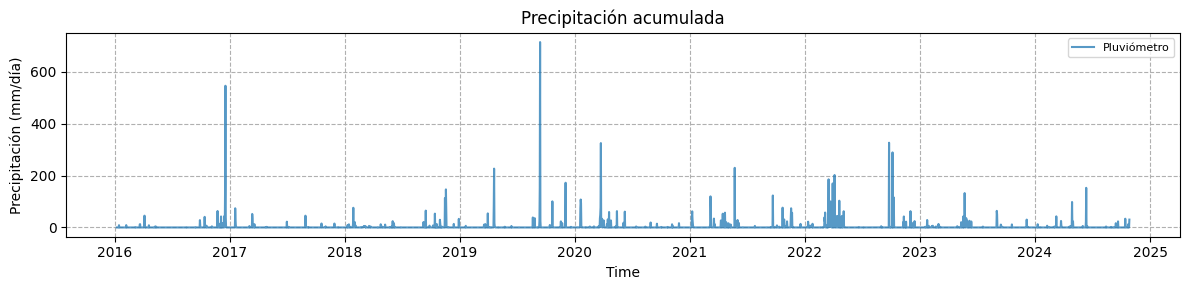

In [91]:
fig, ax = plt.subplots(figsize = (12,3), nrows=1, ncols=1, sharex=True)

ax.plot(df_pluvio["Date"], df_pluvio["Total"], label = "Pluviómetro", alpha=0.75)
ax.legend(loc="upper right", fontsize = 8)
ax.set_ylabel("Precipitación (mm/día)")
ax.set_xlabel("Time")
ax.grid(linestyle = '--')
ax.set_title("Precipitación acumulada")

fig.tight_layout()

## Boyas

Empezamos cargando los datos de la boya más cerca a la desembocadura

In [193]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD7"]#[f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        dataframes[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

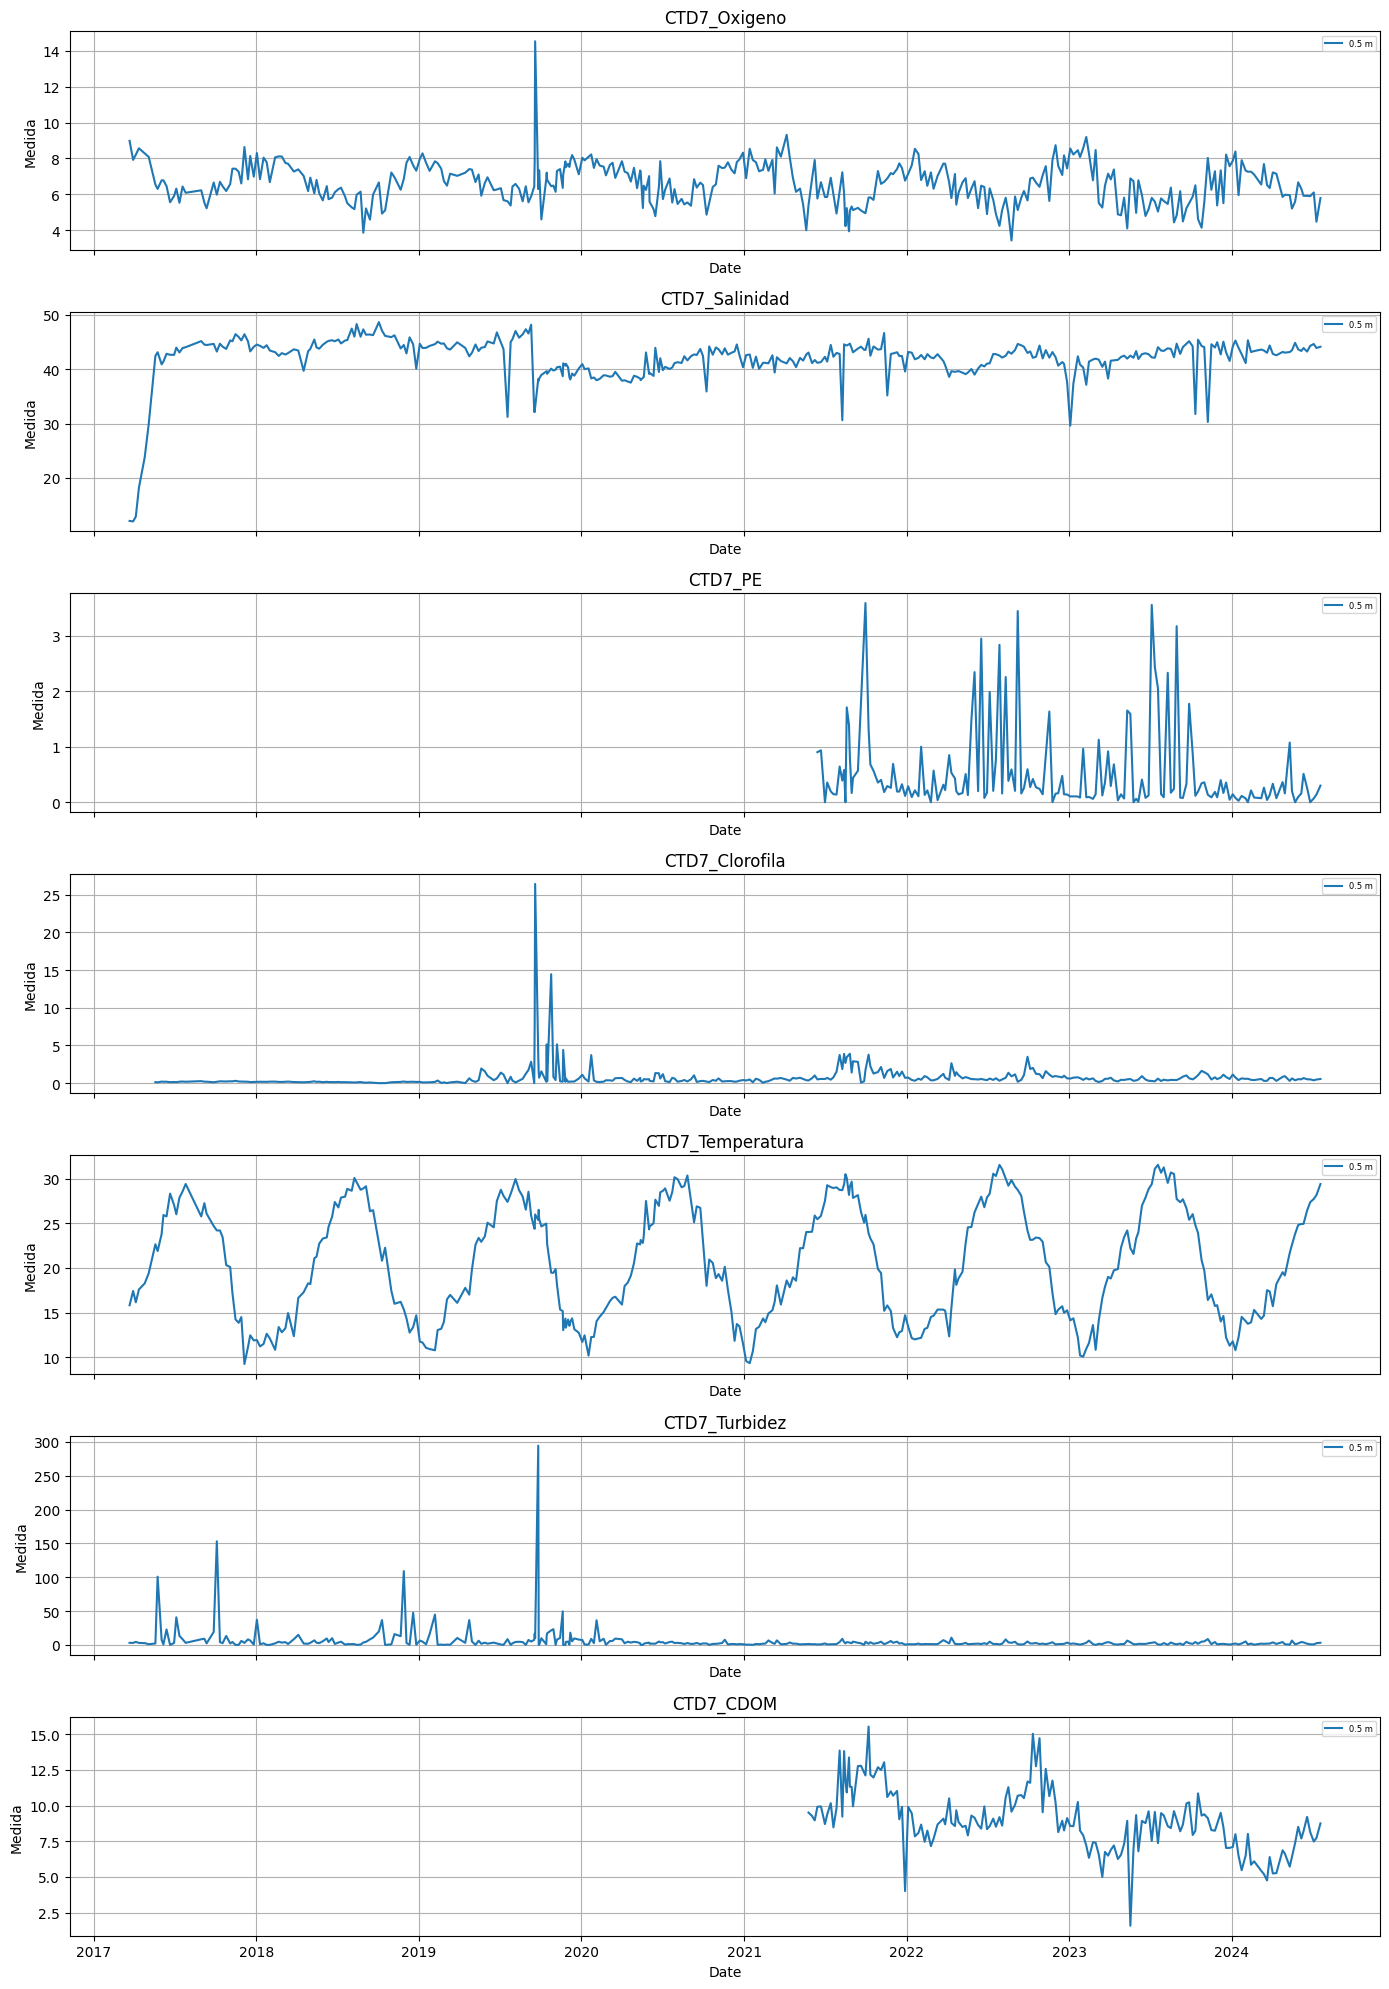

In [194]:
fig, ax = plt.subplots(figsize = (14,len(archivos_csv)*2.5), nrows=len(archivos_csv)-1, ncols=1, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes.items()):
    # Convertir la columna 'Fecha' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    # Graficar cada columna de profundidad
    # for columna in df.columns:
    #     if columna != 'Date':
    depth = "0.5"
    ax[i].plot(df['Date'], df[depth], label=f'{depth} m')
    
    ax[i].set_title(nombre)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Medida')
    ax[i].legend(loc='best', fontsize=6)
    ax[i].grid(True)

fig.tight_layout()

## Plot Pluviometros + Boya CTD7

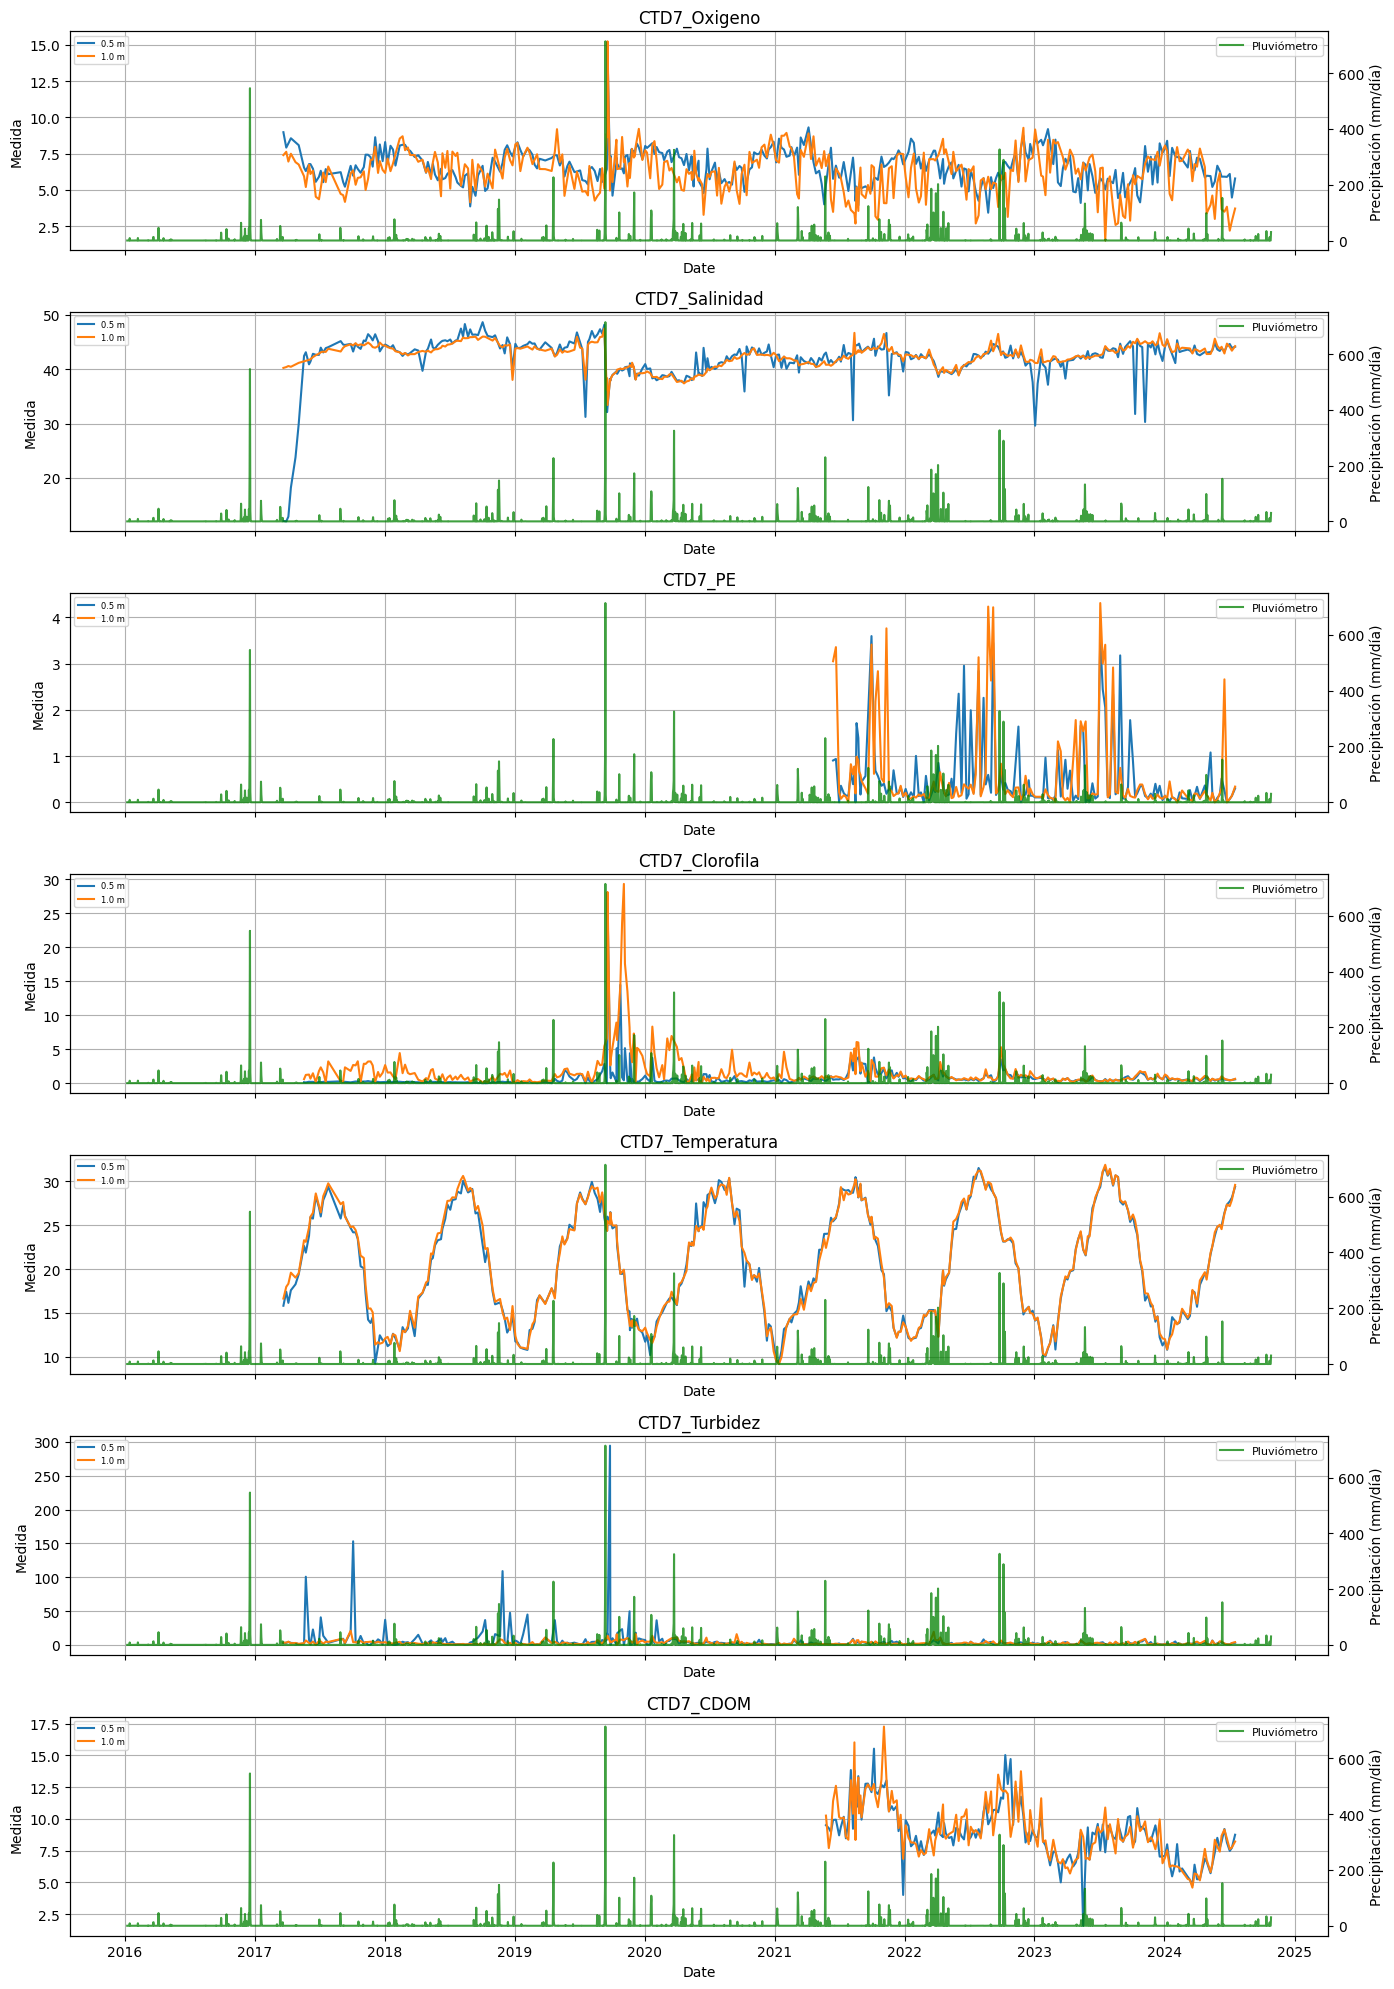

In [97]:
fig, ax = plt.subplots(figsize=(14, len(archivos_csv) * 2.5), nrows=len(archivos_csv)-1, ncols=1, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes.items()):
    # Convertir la columna 'Date' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Graficar la columna de profundidad (ejemplo usando una profundidad específica)
    depths = ["0.5", "1.0"]
    for depth in depths:
        ax[i].plot(df['Date'], df[depth], label=f'{depth} m')

    ax[i].set_title(nombre)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Medida')
    ax[i].legend(loc='upper left', fontsize=6)
    ax[i].grid(True)
    
    # Creamos un segundo eje y para el pluviómetro
    ax2 = ax[i].twinx()
    ax2.plot(df_pluvio["Date"], df_pluvio["Total"], label="Pluviómetro", color="green", alpha=0.75)
    ax2.set_ylabel("Precipitación (mm/día)")
    ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()


## Análisis estadístico

### Comprobar condición de stationarity

In [100]:
from statsmodels.tsa.stattools import adfuller

Test de Augmented Dickey-Fuller test para comprobar stationarity en los pluviómetros.

In [117]:
def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic for {title}: {result[0]}')
    print(f'p-value for {title}: {result[1]}')
    #print(f'Critical Values for {title}: {result[4]}')
    if result[1] > 0.05:
        print(f"Series {title} is non-stationary.")
    else:
        print(f"Series {title} is stationary.")
    print('')

# Comprobar la estacionariedad de cada columna de pluviómetros
print("ADF Test for Original Series")
for column in df_pluvio.columns:
    if column != 'Date':  # Ignorar la columna de fechas
        adf_test(df_pluvio[column], title=column)

ADF Test for Original Series
ADF Statistic for El Estrecho_pluviometro: -27.798531036706194
p-value for El Estrecho_pluviometro: 0.0
Series El Estrecho_pluviometro is stationary.

ADF Statistic for Pozo Estrecho_pluviometro: -25.332844112020368
p-value for Pozo Estrecho_pluviometro: 0.0
Series Pozo Estrecho_pluviometro is stationary.

ADF Statistic for Rbla Albujon_pluviometro: -28.788676177924103
p-value for Rbla Albujon_pluviometro: 0.0
Series Rbla Albujon_pluviometro is stationary.

ADF Statistic for La Puebla_pluviometro: -47.22211615552819
p-value for La Puebla_pluviometro: 0.0
Series La Puebla_pluviometro is stationary.

ADF Statistic for Desemboc Rbla Albujon_pluviometro: -8.858284780765198
p-value for Desemboc Rbla Albujon_pluviometro: 1.506946203092362e-14
Series Desemboc Rbla Albujon_pluviometro is stationary.

ADF Statistic for Total: -13.962685900049681
p-value for Total: 4.490252390548678e-26
Series Total is stationary.



Todos los pluviómetros y el total cumplen la condición de stationarity

Mismo test para las parámetros de la boya.

In [103]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')  # dropna() para manejar valores faltantes
    print(f'ADF Statistic for {title}: {result[0]}')
    print(f'p-value for {title}: {result[1]}')
    #print(f'Critical Values for {title}: {result[4]}')
    if result[1] > 0.05:
        print(f"Series {title} is non-stationary.")
    else:
        print(f"Series {title} is stationary.")
    print('')

# Aplicar la prueba ADF a la columna "0.5" de cada dataframe en el diccionario
print("ADF Test for Original Series - Depth 0.5")
for nombre, df in dataframes.items():
    # Asegurarse de que la columna 'Date' esté en formato datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Comprobar la estacionariedad de la columna '0.5'
    if "0.5" in df.columns:
        adf_test(df["0.5"], title=f'{nombre} - Depth 0.5')


ADF Test for Original Series - Depth 0.5
ADF Statistic for CTD7_Oxigeno - Depth 0.5: -4.768020924234019
p-value for CTD7_Oxigeno - Depth 0.5: 6.258743258528964e-05
Critical Values for CTD7_Oxigeno - Depth 0.5: {'1%': -3.4482453822848496, '5%': -2.8694261442901396, '10%': -2.5709711770439507}
Series CTD7_Oxigeno - Depth 0.5 is stationary.

ADF Statistic for CTD7_Salinidad - Depth 0.5: -9.53145415153469
p-value for CTD7_Salinidad - Depth 0.5: 2.8833756197488065e-16
Critical Values for CTD7_Salinidad - Depth 0.5: {'1%': -3.447909006729481, '5%': -2.8692783343881483, '10%': -2.5708923751111112}
Series CTD7_Salinidad - Depth 0.5 is stationary.

ADF Statistic for CTD7_PE - Depth 0.5: -10.896908371702027
p-value for CTD7_PE - Depth 0.5: 1.18586578857116e-19
Critical Values for CTD7_PE - Depth 0.5: {'1%': -3.471374345647024, '5%': -2.8795521079291966, '10%': -2.5763733302850174}
Series CTD7_PE - Depth 0.5 is stationary.

ADF Statistic for CTD7_Clorofila - Depth 0.5: -3.9723712188246023
p-value

Excepto CDOM, el resto de parámetros sí muestran stationarity

### Cross-Correlation Analysis

In [108]:
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt

In [112]:
# Asegurarse de que la columna 'Date' sea el índice en df_pluvio para alineación de series por fecha
df_pluvio['Date'] = pd.to_datetime(df_pluvio['Date'])
df_pluvio = df_pluvio.set_index('Date')


KeyError: 'Date'

In [149]:
a, b = df_pluvio['Total'].align(dataframes["CTD7_Oxigeno"].set_index('Date')['0.5'], join='inner')

<Figure size 800x400 with 0 Axes>

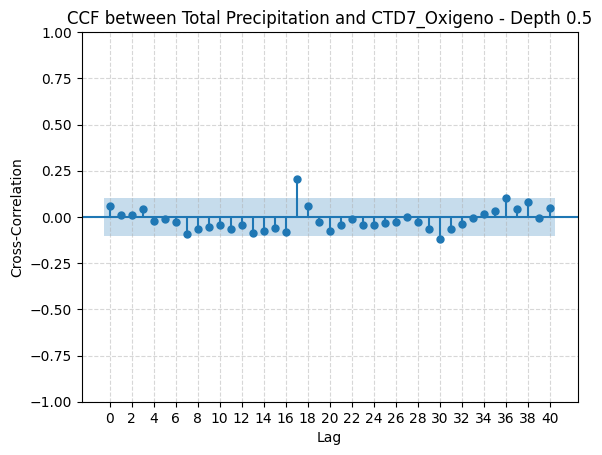

<Figure size 800x400 with 0 Axes>

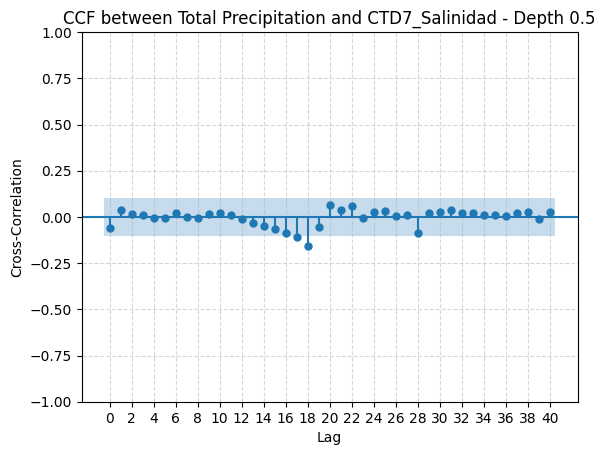

<Figure size 800x400 with 0 Axes>

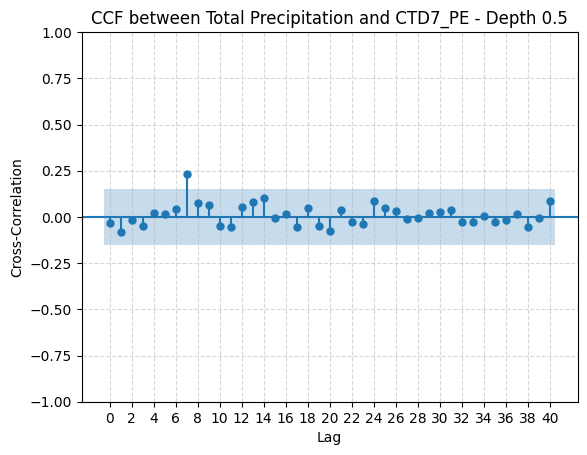

<Figure size 800x400 with 0 Axes>

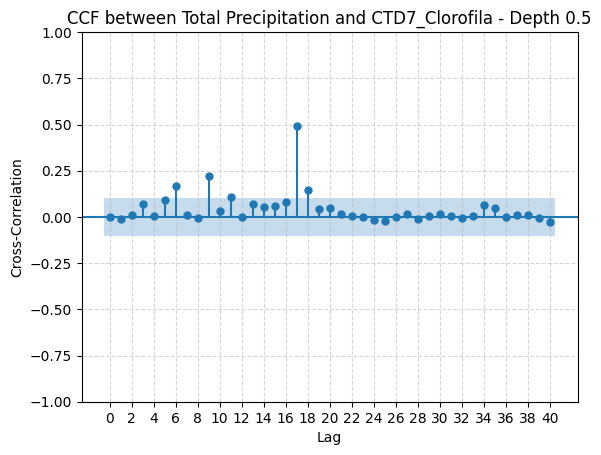

<Figure size 800x400 with 0 Axes>

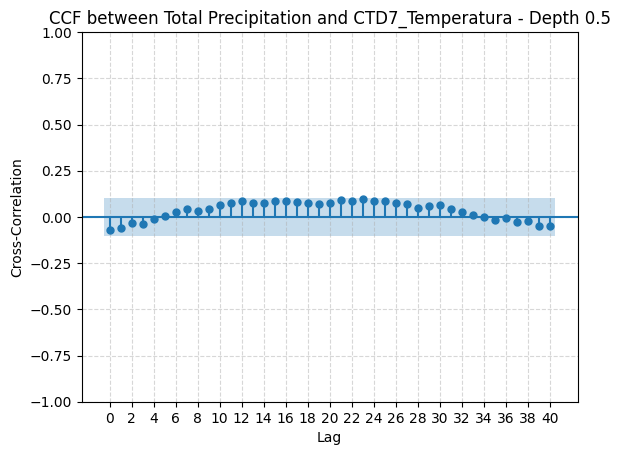

<Figure size 800x400 with 0 Axes>

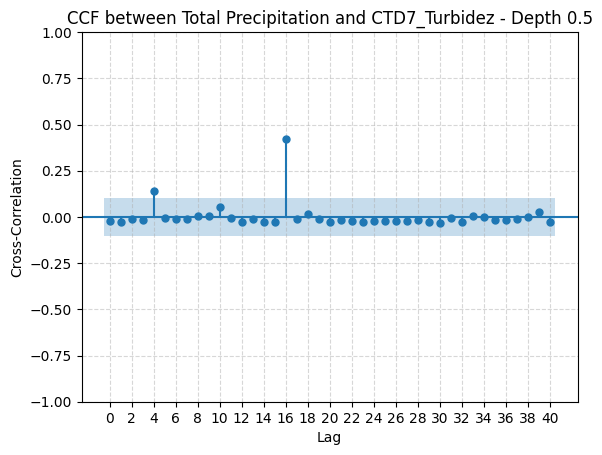

<Figure size 800x400 with 0 Axes>

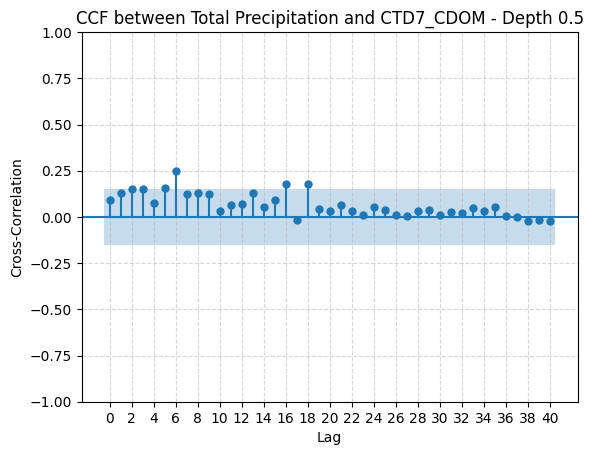

In [145]:

# Recorrer cada dataframe en el diccionario `dataframes` y aplicar el test de cross-correlation
for nombre, df in dataframes.items():
    # Convertir 'Date' a datetime y establecer como índice en cada dataframe
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    
    # Verificar que ambas series tengan datos para la profundidad "0.5" y para la columna 'Total' en `df_pluvio`
    if '0.5' in df.columns and 'Total' in df_pluvio.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth = df_pluvio['Total'].align(df['0.5'], join='inner')
        
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=40)  # Ajusta `lags` según tus necesidades
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Total Precipitation and {nombre} - Depth 0.5')
        plt.show()


### Granger Casuality Test

In [120]:
from statsmodels.tsa.stattools import grangercausalitytests

In [144]:

# Asegurarse de que 'Date' sea el índice en df_pluvio y que las fechas coincidan en cada dataframe
# df_pluvio['Date'] = pd.to_datetime(df_pluvio['Date'])
# df_pluvio = df_pluvio.set_index('Date')
df_pluvio = df_pluvio.asfreq('D')

# Aplicar el test de causalidad de Granger para cada dataframe en el diccionario `dataframes`
for nombre, df in dataframes.items():
    # Asegurarse de que la columna 'Date' esté en formato datetime y sea el índice
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').asfreq('D')
    
    # Verificar que ambas series tengan datos (Total y profundidad 0.5) y alinearlas
    if '0.5' in df.columns and 'Total' in df_pluvio.columns:
        # Alinear las series para que tengan las mismas fechas
        aligned_total, aligned_depth = df_pluvio['Total'].align(df['0.5'], join='inner')
        
        # Crear un nuevo dataframe con las series alineadas
        data = pd.DataFrame({'Total': aligned_total, 'Depth_0.5': aligned_depth})
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        
        # # Determinar el lag óptimo usando VAR
        # model = VAR(data)
        # lag_order = model.select_order(maxlags=20)
        # optimal_lag = lag_order.selected_orders['aic']
        # if optimal_lag == 0:
        #     print(f'Optimal lag is 0')
        #     continue
        #print(f'Optimal lag length for {nombre}: {optimal_lag}')
        
        # Realizar el test de causalidad de Granger con el lag óptimo
        print(f'\nGranger Causality Test for Precipitation causing {nombre} - Depth 0.5:')
        granger_results_total_to_depth = grangercausalitytests(data[['Depth_0.5', 'Total']], maxlag=20)
        print(100*'-')

/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Optimal lag length for CTD7_Oxigeno: 3

Granger Causality Test for Precipitation causing CTD7_Oxigeno - Depth 0.5:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2926  , p=0.5889  , df_denom=375, df_num=1
ssr based chi2 test:   chi2=0.2949  , p=0.5871  , df=1
likelihood ratio test: chi2=0.2948  , p=0.5871  , df=1
parameter F test:         F=0.2926  , p=0.5889  , df_denom=375, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0966  , p=0.9079  , df_denom=372, df_num=2
ssr based chi2 test:   chi2=0.1958  , p=0.9067  , df=2
likelihood ratio test: chi2=0.1958  , p=0.9068  , df=2
parameter F test:         F=0.0966  , p=0.9079  , df_denom=372, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7745  , p=0.5088  , df_denom=369, df_num=3
ssr based chi2 test:   chi2=2.3675  , p=0.4997  , df=3
likelihood ratio test: chi2=2.3601  , p=0.5011  , df=3
parameter F test:         F=0.7745  , p=0.5088  , df

/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Optimal lag length for CTD7_Clorofila: 17

Granger Causality Test for Precipitation causing CTD7_Clorofila - Depth 0.5:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0809  , p=0.7762  , df_denom=369, df_num=1
ssr based chi2 test:   chi2=0.0816  , p=0.7752  , df=1
likelihood ratio test: chi2=0.0816  , p=0.7752  , df=1
parameter F test:         F=0.0809  , p=0.7762  , df_denom=369, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2145  , p=0.8071  , df_denom=366, df_num=2
ssr based chi2 test:   chi2=0.4348  , p=0.8046  , df=2
likelihood ratio test: chi2=0.4345  , p=0.8047  , df=2
parameter F test:         F=0.2145  , p=0.8071  , df_denom=366, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3425  , p=0.7946  , df_denom=363, df_num=3
ssr based chi2 test:   chi2=1.0474  , p=0.7898  , df=3
likelihood ratio test: chi2=1.0459  , p=0.7901  , df=3
parameter F test:         F=0.3425  , p=0.7946 

/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Los test de causalidad de Granger indican que ninguno de los parámetros de la boya puede ser predicho por los lags del pluviómetro.

### Reconstruir serie temporal completa

In [197]:
dataframes["CTD7_CDOM"]

,Date,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5
0,2021-05-25,9.503551,10.255163,10.207227,10.458692,10.215709,10.701057,11.769114,11.609742,11.725950
1,2021-06-02,9.266659,7.697766,7.491759,7.426442,7.467684,7.848140,7.993415,7.687457,7.924946
2,2021-06-08,8.958155,8.809979,8.955331,9.065762,8.767858,8.781536,9.166398,9.393375,10.087952
3,2021-06-14,9.913384,11.406258,10.999558,11.143224,11.993075,12.018544,12.056605,11.914720,11.298031
4,2021-06-22,9.933765,12.602938,13.530883,13.080631,13.736329,13.287278,13.529207,13.618188,13.389248
...,...,...,...,...,...,...,...,...,...,...
161,2024-06-18,9.203428,9.158572,8.538445,8.929353,8.906344,9.216323,9.240074,9.532294,9.762650
162,2024-06-25,8.138363,8.442359,7.846620,7.643094,9.320182,9.553912,9.441969,9.907160,9.578840
163,2024-07-03,7.475750,7.616372,6.923813,6.885558,6.882208,6.656454,6.578804,6.452187,6.842533
164,2024-07-09,7.724953,7.746856,7.661120,8.072733,7.964108,7.793841,7.906250,7.862588,7.534921


In [198]:
dataframes_interpolados = dataframes.copy()
# Assuming your dictionary of dataframes is called `dataframes_dict`
for name, df in dataframes_interpolados.items():
    
    df = df.set_index('Date')
    # Resample to daily frequency, introducing NaN for missing days
    df = df.resample('D').asfreq()
    
    # Interpolate missing values linearly
    df = df.interpolate(method='linear')
    
    # O con ARIMA
    # for col in df.columns:
    #     #if col != 'Fecha':
    #     df[col] = arima_interpolate(df, col)

    # Reset the index to make 'Date' a column again, if necessary
    df.reset_index(inplace=True)
    
    # Store the modified dataframe back in the dictionary
    dataframes_interpolados[name] = df

In [200]:
# Asegurarse de que la columna 'Date' sea el índice en df_pluvio para alineación de series por fecha
df_pluvio['Date'] = pd.to_datetime(df_pluvio['Date'])
df_pluvio = df_pluvio.set_index('Date')

<Figure size 800x400 with 0 Axes>

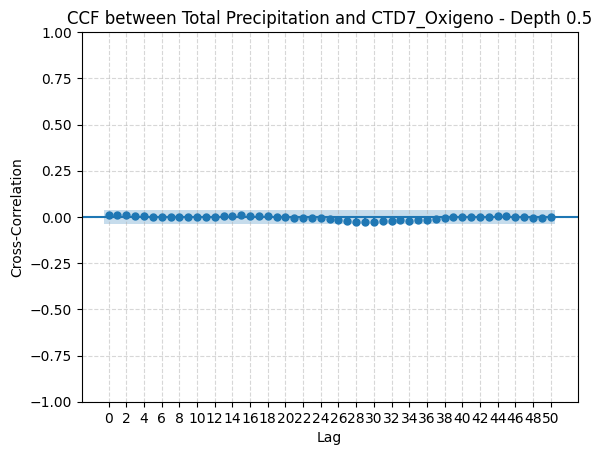

<Figure size 800x400 with 0 Axes>

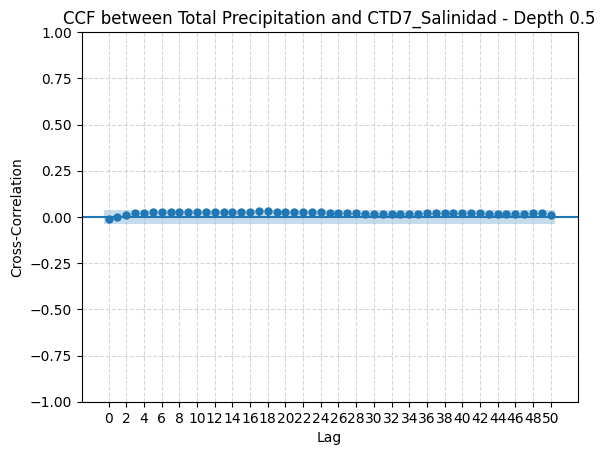

<Figure size 800x400 with 0 Axes>

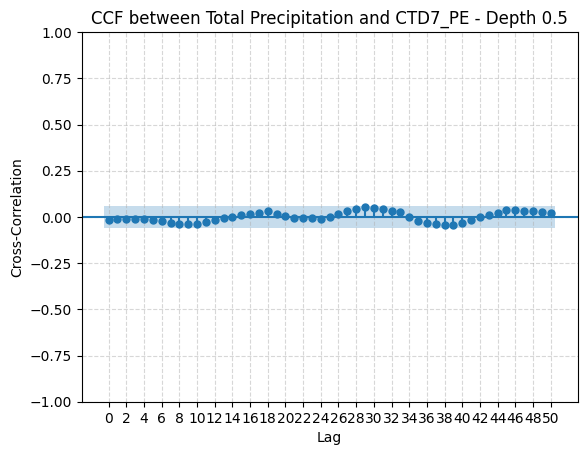

<Figure size 800x400 with 0 Axes>

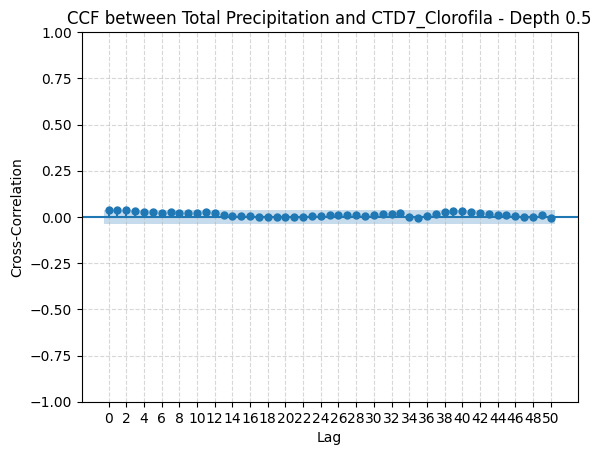

<Figure size 800x400 with 0 Axes>

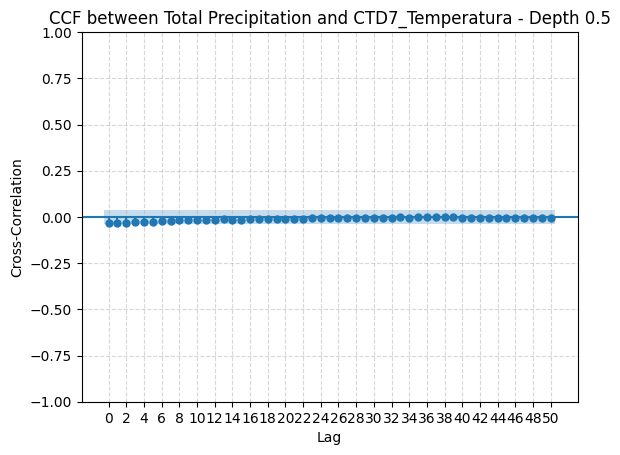

<Figure size 800x400 with 0 Axes>

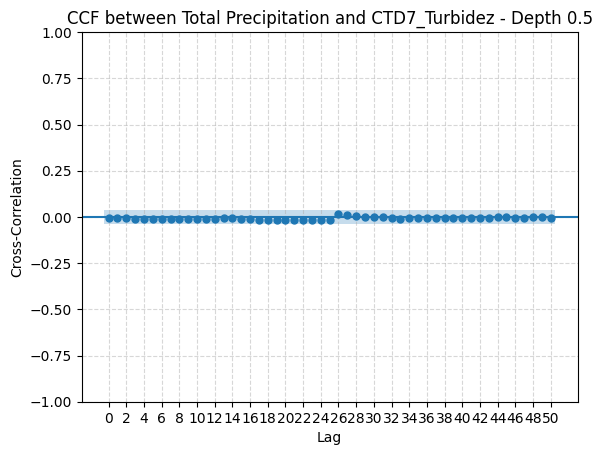

<Figure size 800x400 with 0 Axes>

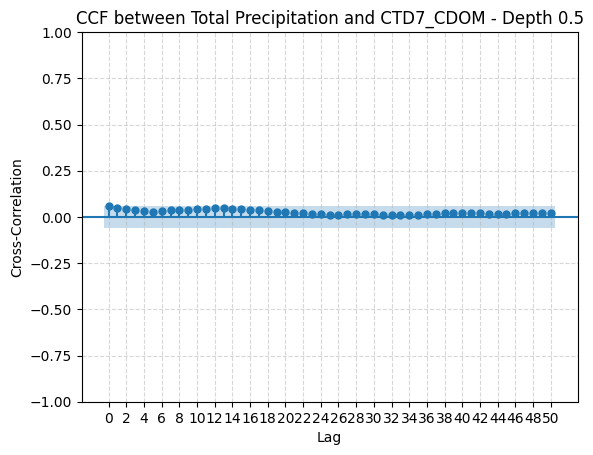

In [186]:
for nombre, df in dataframes_interpolados.items():
    # Convertir 'Date' a datetime y establecer como índice en cada dataframe
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    
    # Verificar que ambas series tengan datos para la profundidad "0.5" y para la columna 'Total' en `df_pluvio`
    if '0.5' in df.columns and 'Total' in df_pluvio.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth = df_pluvio['Total'].align(df['0.5'], join='inner')
        
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=50)  # Ajusta `lags` según tus necesidades
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,52,2))
        plt.title(f'CCF between Total Precipitation and {nombre} - Depth 0.5')
        plt.show()